# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish simple **benchmarks** to contextualise the results.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [Evaluation & Save Utilities](#evaluation--save-utilities)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
    - [Community Area Encoding](#community-area-encoding)
- [Feature Selection](#feature-selection)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [Embed Dimension Search](#embed-dimension-search)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Tuned Deeper — Training](#4212-tuned-deeper--training)
  - [4.2.12 Tuned Deeper — Evaluation](#4212-tuned-deeper--evaluation)
- [4.2.13 Wider Model — Training](#4213-wider-model--training)
  - [4.2.13 Wider Model — Evaluation](#4213-wider-model--evaluation)
- [4.2.14 Hyperparameter Search — Wider Model](#4214-hyperparameter-search--wider-model)
  - [4.2.14 Tuned Wider — Training](#4214-tuned-wider--training)
  - [4.2.14 Tuned Wider — Evaluation](#4214-tuned-wider--evaluation)
- [4.2.15 Visualization: Trip Count Distribution](#4215-visualization-trip-count-distribution)
- [4.2.16 Visualization: Architecture Comparison](#4216-visualization-architecture-comparison)
  - [Learning Curves](#learning-curves)
  - [Statistical Significance — Wilcoxon Signed-Rank](#statistical-significance--wilcoxon-signed-rank)


In [47]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime

# model visualization
from torchinfo import summary

# reset working dir
import os
from pathlib import Path


In [48]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [49]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_24h.parquet")

In [50]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28100,2025-12-31,490872,73,residential,11,10,53.181818,1322.818182,10.206364,27.328182,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
28101,2025-12-31,490872,74,residential,6,5,63.000000,1984.333333,11.760000,33.335000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
28102,2025-12-31,490872,75,residential,14,13,39.545455,1283.214286,11.902857,30.803571,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
28103,2025-12-31,490872,76,airport,1553,824,127.081784,2054.041211,14.628880,38.528210,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 4.2.1 Data Information

In [51]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# At 24h aggregation there is exactly one row per community area per day, so this
# just counts the daily buckets each area is observed in (temporal coverage,
# not a time-of-day pattern — hour_of_day is constant at this aggregation).
area_row_counts = data.groupby('pickup_community_area').size()

print(f"\n--- Rows per community area (daily buckets) ---")
print(f"Unique community areas     : {len(area_row_counts):>8,}")
print(f"Avg daily buckets per area : {area_row_counts.mean():>8.1f}")
print(f"Min daily buckets per area : {area_row_counts.min():>8,}")
print(f"Max daily buckets per area : {area_row_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :     28,105
Unique combinations (no time) :     28,105
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :   28,105 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :       77
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :      318  (1.1%)
Non-zero-demand rows           :   27,787  (98.9%)


In [52]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.2 Model Configurations

In [53]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-2
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 300

# --- loss / output ---
LOSS               = "mae"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

# --- community-area embedding ---
CA_EMBED_DIM       = 16

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    CA_EMBED_DIM   = CA_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}


HP_SEARCH_SEEDS        = SEEDS   # same single seed for hp search and final training
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-4, 5e-4, 8e-4, 2e-3, 5e-3, 8e-3, 2e-2, 5e-2, 8e-2, 2e-1, 5e-1, 8e-1]   # step 1: one representative per decade
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]    # 0.0 = unregularized control
HP_FINE_STEPS  = list(range(1, 10))           # step 2: multipliers inside the winning decade


## 4.2.3 Model Definition

In [54]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_ca, embed_dim):
        super().__init__()
        self.ca_embed = nn.Embedding(n_ca, embed_dim)
        nn.init.normal_(self.ca_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, ca_idx):
        emb = self.ca_embed(ca_idx)           # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)     # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None, test_data=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    _embed_dim = embed_dim if embed_dim is not None else config.CA_EMBED_DIM
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_CA, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(ca_train, dtype=torch.long),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    ca_val_t = torch.as_tensor(ca_val, dtype=torch.long).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)
    if test_data is not None:   # optional (X, y, group) on the training scale — monitoring only
        X_test_t = torch.as_tensor(test_data[0], dtype=torch.float32).to(device)
        y_test_t = torch.as_tensor(test_data[1], dtype=torch.float32).to(device)
        g_test_t = torch.as_tensor(test_data[2], dtype=torch.long).to(device)
    history = {"train": [], "val": [], "test": []}

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, cb, yb in train_dl:
            xb, cb, yb = xb.to(device), cb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, cb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, ca_val_t), y_val_t).item()
            if test_data is not None:
                history["test"].append(loss_fn(model(X_test_t, g_test_t), y_test_t).item())
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    model.history = history   # per-epoch losses for the learning-curve plots
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch using Optuna)

Two-step search→fine grid search (Optuna `GridSampler`):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, three representative values
   per decade to locate the best decade of the learning rate for the finer hyperparameter search.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade from step 1.
    - e.g. decade step 1 identified 1e-3 to be the best decade, then [1e-3, 2e-3, ..., 9e-3] are evaluated to find the best LR.

This way only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result.

In [55]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  ca_train, ca_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated exactly
    once, so this is a true exhaustive grid search; the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median. Each trial trains one model per seed in HP_SEARCH_SEEDS and is
    scored by the mean validation loss, so the search is reproducible.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning is judged on the first seed's run only
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """Fine grid inside the decade of `best`, e.g. 5e-4 -> [2e-4, 4e-4, 5e-4, 6e-4, 8e-4].

    best = 0.0 (unregularized weight decay) has no decade and stays [0.0].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        ca_train, ca_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades. Both steps are exhaustive grids, so
    only rough orders of magnitude need to be known upfront."""
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'=== Step 1/2 — decade grid ({arch_label}) ===\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           ca_train, ca_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n=== Step 2/2 — fine grid in winning decades ({arch_label}) ===')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         ca_train, ca_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers functions: `evaluate_models` computes the test-set metrics for the models and returns the result rows, `save_results` appends them to the results CSV.

In [56]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, ca_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    ca_test_t  = torch.as_tensor(ca_test,  dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, ca_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        # test loss under the training criterion, so train/val/test are comparable
        _y_target = y_test if IS_POISSON else y_test_log
        if config.LOSS == "mae":
            _test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
        elif config.LOSS == "mse":
            _test_loss = float(np.mean((preds_raw - _y_target) ** 2))
        elif config.LOSS == "poisson_nll":
            _test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
        else:  # nb_nll — evaluate with the model's trained dispersion
            _test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                           torch.as_tensor(_y_target, dtype=torch.float32),
                                           model.log_theta.detach().cpu()))
        test_losses.append(_test_loss)

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check ({config.LOSS}, {'raw counts' if IS_POISSON else 'log1p scale'}) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [57]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_24h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

The values below are illustrative (schematic), not a specific record.

```
One row of raw data  —  one community area in one 24 h bucket
┌─────────────────────────┬───────────────────────────────────┬─────────────┐
│  pickup_community_area  │ is_weekend, month_sin, area_km2,  │ trip_count  │
│            8            │    1,       0.50,     36.4, …     │      5      │
└────────────┬────────────┴─────────────────┬─────────────────┴──────┬──────┘
             │                              │                        │
             ▼                              ▼                        ▼
         ca_vocab                    StandardScaler             np.log1p(y)
             8                   [1.59, 0.40, -0.51, …]            1.79
            → 7                (n_num dims, fit on train)    (training target)
             │                              │
             ▼                              │
 Embedding table                            │
 (N_CA rows × CA_EMBED_DIM)                 │
 row 7: [0.12, -0.31, …]                    │
             │                              │
             └──────────────┬───────────────┘
                            ▼
                    torch.cat(x, emb)
             [0.12, -0.31, …, 1.59, 0.40, …]
               (CA_EMBED_DIM + n_num dims)
                            │
                            ▼
             ┌─────────────────────────────┐
             │  Linear(dim → 64)           │
             │  ReLU                       │   ← 2 blocks × 64   (baseline)
             │  Linear(64 → 64)            │      2 blocks × 256 (wider)
             │  ReLU                       │      8 blocks × 64  (deeper)
             │  Linear(64 → 1)             │
             │  Softplus                   │   ← keeps the log1p output ≥ 0
             └─────────────────────────────┘
                            │
                            ▼
            ŷ_log   (predicted log1p demand)
                            │
                            ▼  np.expm1(ŷ_log) ← evaluation only, never in the loss
             ŷ   (predicted trip count, ≥ 0)
```

**Target scale.** The network is trained on `log1p(trip_count)`, so both the `Softplus` output and
the training criterion (`config.LOSS = "mae"`) live on the log1p scale — `Softplus` is what keeps
the back-transformed prediction non-negative. Raw trip counts reappear only at evaluation time,
where `expm1` inverts the transform before evaluation metrics are computed.

**Community area embedding.** The table holds one row per community area seen in training
plus one reserved *unknown* row for community areas that appear only in val/test. It
starts with near-zero weights and is updated by backprop alongside all other parameters, so the
network learns which community areas behave similarly. `CA_EMBED_DIM` is not fixed upfront: the embed
dimension search below selects it from `[8, 16, 32]`.

## 4.2.6 Train / Val / Test Split

We split rows chronologically into **70 % train / 15 % val / 15 % test** using
`train_test_split`.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [58]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :    19,673 rows
Val   :     4,216 rows
Test  :     4,216 rows


In [59]:
train_data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,60,50,39.069767,1222.233333,8.207667,23.925833,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,64,54,76.578947,1492.218750,7.779688,23.623750,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,140,124,27.732558,904.878571,5.694357,18.320786,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,33,33,47.368421,882.424242,4.885455,16.221515,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,22,22,26.666667,1152.409091,5.806364,19.983636,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.

We split the features into LEAKAGE, CYCLIC, ID and TARGET columns to have a better overview of how the FEATURE columns are composed. All three column types: LEAKAGE, RAW_CYCLIC, ID are removed since they are not relevant for our models.
- LEAKAGE contain the columns that need to be removed, either because they leak undesired information into our models (e.g. idle_time, avg_tip etc.), or because they do not add any informational value or even harm the model
- RAW_CYCLIC are the raw temporal columns that have not been transformed (transformed columns are included in FEATURE column)
- ID contains columns we need to remove, e.g. bucket_index or pickup_community_area


#### Community Area Encoding

Community area identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network.

In [60]:
LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    # 'temperature_2m', 
    # 'apparent_temperature',
    # 'precipitation',
    # 'rain', 'snowfall',
    # 'wind_speed_10m',
    # 'cloud_cover', 'is_day', 
    # 'area_km2',
    # 'dist_to_nearest_airport_km',
    # 'dist_to_nearest_train_station_km',
    # 'dist_to_nearest_stadium_km',
    # 'train_station_per_km2',
    # 'restaurants_per_km2',
    # 'bars_and_clubs_per_km2',
    # 'hotels_per_km2',
    # 'hospitals_per_km2',
    # 'universities_per_km2',
    # 'attractions_per_km2',
    # 'poi_density_total_per_km2'
    ]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Numeric features (29): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'is_day', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'universities_per_km2', 'attractions_per_km2', 'poi_density_total_per_km2']


## Feature Selection

We base our decision of feature selection on two selection methods:

1. correlation matrix
2. model-based feature importance

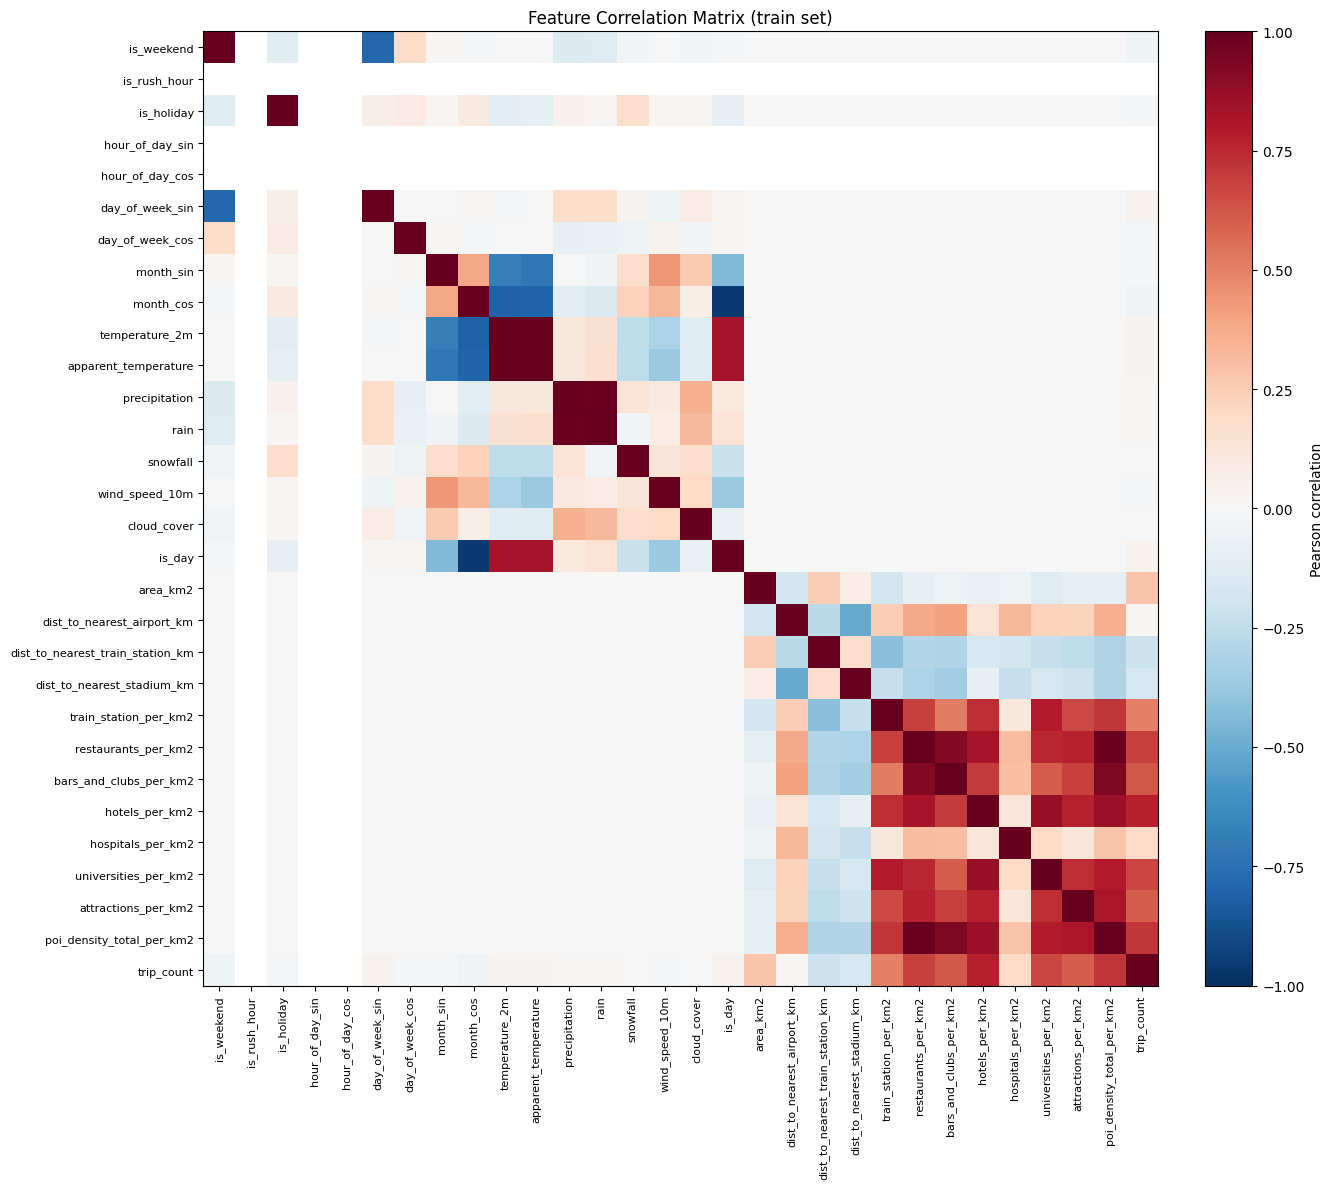

Feature pairs with |correlation| >= 0.8:
  temperature_2m                      vs apparent_temperature                 r=+0.996
  restaurants_per_km2                 vs poi_density_total_per_km2            r=+0.991
  precipitation                       vs rain                                 r=+0.986
  month_cos                           vs is_day                               r=-0.955
  bars_and_clubs_per_km2              vs poi_density_total_per_km2            r=+0.930
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  hotels_per_km2                      vs universities_per_km2                 r=+0.871
  hotels_per_km2                      vs poi_density_total_per_km2            r=+0.866
  temperature_2m                      vs is_day                               r=+0.826
  apparent_temperature                vs is_day                               r=+0.826
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820
  

In [61]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")


In [62]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")


                         feature  rf_importance  perm_importance  perm_importance_std
                  hotels_per_km2       0.618594         1.277173             0.013740
                        area_km2       0.124957         0.123411             0.001294
      dist_to_nearest_airport_km       0.107006         0.114337             0.001212
                 day_of_week_sin       0.023957         0.039944             0.001389
      dist_to_nearest_stadium_km       0.029517         0.039312             0.000621
                      is_weekend       0.010737         0.011580             0.000519
                       month_cos       0.007685         0.009707             0.000267
                 day_of_week_cos       0.004756         0.009188             0.000652
                          is_day       0.005550         0.007095             0.000252
            apparent_temperature       0.007741         0.006690             0.000206
                  wind_speed_10m       0.003962       

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Selection.                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    # trip-derived aggregates from the same time bucket -> target leakage
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]

# Non-leakage columns we deliberately drop, based on the two selection cells
# above (correlation matrix + model-based / permutation importance).
DROP_COLS = [
    # --- redundant: |r| >= 0.8 with a feature we keep (correlation matrix) ---
    'temperature_2m', 'apparent_temperature',   # r=+0.996 with each other
    'rain', 'precipitation',                     # r=+0.986 with each other
    'is_day',                                    # collinear with month_cos / temperature
    'train_station_per_km2',                     # r=+0.833 with poi_density_total_per_km2
    'universities_per_km2',                      # collinear with hotels / attractions / poi_density
    'poi_density_total_per_km2',                 # aggregate collinear with its POI components
    # --- negligible model-based importance (permutation importance ~ 0) ---
    'wind_speed_10m', 'cloud_cover', 'snowfall',
    # considered but kept:
    # 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km',
    # 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2',
    # 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2',
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + DROP_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

In [64]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# community-area embedding indices — vocabulary built from the training set only;
# areas unseen in training map to a reserved "unknown" index
ca_vocab = {a: i for i, a in enumerate(sorted(train_data['pickup_community_area'].unique()))}
UNK_CA   = len(ca_vocab)
N_CA     = len(ca_vocab) + 1   # +1 for the unknown bucket

ca_train = train_data['pickup_community_area'].map(ca_vocab).astype(int).values
ca_val   = val_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values
ca_test  = test_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values

print(f"Unique community areas (train) : {len(ca_vocab)}  |  embed dim : {CA_EMBED_DIM}")
print(f"Unseen areas  val: {(ca_val == UNK_CA).sum()}   test: {(ca_test == UNK_CA).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Target scale : log1p
Unique community areas (train) : 77  |  embed dim : 16
Unseen areas  val: 0   test: 0

X_train : (19673, 18)   y_train : (19673,)
X_val   : (4216, 18)     y_val   : (4216,)
X_test  : (4216, 18)    y_test  : (4216,)


## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × day-of-week pair, predict the mean `trip_count` observed in the training split. At 24h aggregation there is exactly one row per community area and day, so day-of-week is the finest temporal grouping that still averages over several observations. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat the benchmark models is not adding value for our business client. In that case the decision is fixed: the model should not be implemented and the benchmark should be chosen as their prediction model.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [65]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'day_of_week'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'day_of_week']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'day_of_week'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × day-of-week)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157

Historical mean (area × hour)        R²=0.8676  MAE=60.8814  RMSE=227.1378  NRMSE=1.2653  MAPE=74.1%
Ridge regression                     R²=0.6869  MAE=96.3022  RMSE=349.2573  NRMSE=1.9456  MAPE=120.0%


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (with early stopping).

In [66]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed={HP_SEARCH_SEEDS[0]}, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=HP_SEARCH_SEEDS[0], device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
CA_EMBED_DIM        = best_embed_dim
config.CA_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {CA_EMBED_DIM}  →  set as global CA_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=5

  embed_dim=  8  val_loss=0.3580
  embed_dim= 16  val_loss=0.3435
  embed_dim= 32  val_loss=0.3262

Best embed_dim: 32  →  set as global CA_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` and report
the validation loss.


In [67]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_CA, CA_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
c_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, c_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 18]                   [1]                       --
├─Embedding: 1-1                         [1]                       [1, 32]                   2,496
├─Sequential: 1-2                        [1, 50]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 50]                   [1, 64]                   3,264
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 9,985
Traina

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 18]                   [1]                       --
├─Embedding: 1-1                         [1]                       [1, 32]                   2,496
├─Sequential: 1-2                        [1, 50]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 50]                   [1, 64]                   3,264
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 9,985
Traina

In [68]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/300
  loss: 1.5032  val_loss: 0.8801 ✓
Epoch   2/300
  loss: 0.6862  val_loss: 0.6007 ✓
Epoch   3/300
  loss: 0.4656  val_loss: 0.4874 ✓
Epoch   4/300
  loss: 0.3268  val_loss: 0.4333 ✓
Epoch   5/300
  loss: 0.2821  val_loss: 0.3886 ✓
Epoch   6/300
  loss: 0.2488  val_loss: 0.3918  (no improvement 1/10)
Epoch   7/300
  loss: 0.2329  val_loss: 0.3596 ✓
Epoch   8/300
  loss: 0.2139  val_loss: 0.3523 ✓
Epoch   9/300
  loss: 0.2157  val_loss: 0.3739  (no improvement 1/10)
Epoch  10/300
  loss: 0.2205  val_loss: 0.3498 ✓
Epoch  11/300
  loss: 0.2058  val_loss: 0.3377 ✓
Epoch  12/300
  loss: 0.2173  val_loss: 0.3477  (no improvement 1/10)
Epoch  13/300
  loss: 0.2017  val_loss: 0.3262 ✓
Epoch  14/300
  loss: 0.2096  val_loss: 0.3427  (no improvement 1/10)
Epoch  15/300
  loss: 0.2063  val_loss: 0.3549  (no improvement 2/10)
Epoch  16/300
  loss: 0.2068  val_loss: 0.3344  (no improvement 3/10)
Epoch  17/300
  loss: 0.1966  val_loss: 0.3472  (no improvement 4/10)
Epoch  

### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [69]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, ca_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0 layer weight stats:
    ca_embed.weight  shape=(78, 32)      max|w|=0.4299  mean|w|=0.0360  norm=2.7634
    net.0.weight    shape=(64, 50)      max|w|=0.8177  mean|w|=0.1568  norm=11.2119
    net.2.weight    shape=(64, 64)      max|w|=0.6794  mean|w|=0.1405  norm=11.2958
    net.4.weight    shape=(1, 64)       max|w|=0.5927  mean|w|=0.1506  norm=1.5190
  seed=0  R²=0.8260  MAE=63.5891  NRMSE=1.4504  MAPE=50.3%  | zeros 0/67  false=0  | pred min=0.8 max=3424.6

--- original scale ---
Baseline  R²    : 0.8260 ± 0.0000
Baseline  MAE   : 63.5891 ± 0.0000
Baseline  RMSE  : 260.3761 ± 0.0000
Baseline  NRMSE : 1.4504 ± 0.0000
Baseline  MAPE  : 50.27% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Baseline  Correct-zero : 0.0 ± 0.0  (out of 67)
Baseline  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 0.8266 ± 0.

Tuned Baseline  R²=0.9313 ± 0.0020  MAE=4.4563 ± 0.0101  NRMSE=0.7787 ± 0.0113


In [70]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (28 columns)
          timestamp loss    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay     mape
2026-07-20T00:07:05  NaN baseline         2     64           0.05        1024     0  0.326183                 67   179.515655 0.825991 63.589067 260.376118 1.450437 0.91882 0.369486   0.47966   0.150816             0           0  0.826575 3424.614502                   NaN              relu           mae           0.0 50.26714


## 4.2.10 Hyperparameter Search — Baseline Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_BASELINE]`.


In [71]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (baseline) ===

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-02    5.00e-04      0.3265  complete
   2    5.00e-04    0.00e+00      0.3566  complete
   3    2.00e-02    5.00e-03      0.3311  complete
   4    5.00e-02    5.00e-03      0.3327  complete
   5    8.00e-02    0.00e+00      0.3348  complete
   6    2.00e-01    5.00e-04      0.3045  complete
   7    8.00e-02    5.00e-03      0.3526  pruned
   8    5.00e-01    0.00e+00      0.4841  pruned
   9    5.00e-04    5.00e-02      1.3022  pruned
  10    8.00e-04    5.00e-03      1.1005  pruned
  11    8.00e-04    5.00e-02      1.0994  pruned
  12    5.00e-02    5.00e-02      0.4408  pruned
  13    8.00e-02    5.00e-04      0.3717  pruned
  14    2.00e-02    5.00e-02      0.5047  pruned
  15    8.00e-01    5.00e-02      1.0514  pruned
  16    2.00e-04    5.00e-03     

{'lr': 0.2, 'weight_decay': 0.0005}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [72]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.2, 'weight_decay': 0.0005}

Epoch   1/300
  loss: 1.2132  val_loss: 0.7505 ✓
Epoch   2/300
  loss: 0.5479  val_loss: 0.4527 ✓
Epoch   3/300
  loss: 0.3193  val_loss: 0.3613 ✓
Epoch   4/300
  loss: 0.2927  val_loss: 0.3708  (no improvement 1/10)
Epoch   5/300
  loss: 0.2382  val_loss: 0.4086  (no improvement 2/10)
Epoch   6/300
  loss: 0.2353  val_loss: 0.3438 ✓
Epoch   7/300
  loss: 0.2441  val_loss: 0.3615  (no improvement 1/10)
Epoch   8/300
  loss: 0.2290  val_loss: 0.3446  (no improvement 2/10)
Epoch   9/300
  loss: 0.2273  val_loss: 0.3394 ✓
Epoch  10/300
  loss: 0.2289  val_loss: 0.3045 ✓
Epoch  11/300
  loss: 0.2336  val_loss: 0.3330  (no improvement 1/10)
Epoch  12/300
  loss: 0.2536  val_loss: 0.4500  (no improvement 2/10)
Epoch  13/300
  loss: 0.2221  val_loss: 0.3525  (no improvement 3/10)
Epoch  14/300
  loss: 0.2137  val_loss: 0.3363  (no improvement 4/10)
Epoch  15/300
  loss: 0.2068  val_loss: 0.3663  (no improvement 5/10)
Epoch  16/300
  loss: 0.2370  

### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [73]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.9106  MAE=46.3880  NRMSE=1.0396  MAPE=47.1%  | zeros 0/67  false=0  | pred min=0.5 max=4827.7

--- original scale ---
Tuned Baseline  R²    : 0.9106 ± 0.0000
Tuned Baseline  MAE   : 46.3880 ± 0.0000
Tuned Baseline  RMSE  : 186.6172 ± 0.0000
Tuned Baseline  NRMSE : 1.0396 ± 0.0000
Tuned Baseline  MAPE  : 47.08% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Baseline  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Baseline  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Baseline  Pred min : 0.5260 ± 0.0000
Tuned Baseline  Pred max : 4827.7490 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.2289    0.3045    0.2079


In [74]:
results_df

,timestamp,training_loss,model,n_layers,width,learning_rate,weight_decay,batch_size,seed,hidden_activation,...,nrmse,mape,r2_log,mae_log,rmse_log,nrmse_log,correct_zero,false_zero,pred_min,pred_max
0,2026-07-20T00:07:05,mae,baseline,2,64,0.05,0.0,1024,0,relu,...,1.450437,50.26714,0.91882,0.369486,0.47966,0.150816,0,0,0.826575,3424.614502


In [75]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (28 columns)
          timestamp loss          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T00:08:49  NaN baseline_tuned         2     64            0.2        1024     0  0.304451                 67   179.515655 0.910613 46.38799 186.617193 1.039559 0.926633 0.346276  0.455994   0.143375             0           0  0.525962 4827.749023                   NaN              relu           mae        0.0005 47.084342


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (8 hidden layers, 64 units)`.
Width is fixed; depth increased (x4) relative to the baseline.


In [76]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/300


  loss: 1.7691  val_loss: 1.0964 ✓
Epoch   2/300
  loss: 0.8082  val_loss: 0.7870 ✓
Epoch   3/300
  loss: 0.6595  val_loss: 0.7650 ✓
Epoch   4/300
  loss: 0.5645  val_loss: 0.5097 ✓
Epoch   5/300
  loss: 0.4438  val_loss: 0.4641 ✓
Epoch   6/300
  loss: 0.3994  val_loss: 0.4750  (no improvement 1/10)
Epoch   7/300
  loss: 0.3454  val_loss: 0.4805  (no improvement 2/10)
Epoch   8/300
  loss: 0.3137  val_loss: 0.3679 ✓
Epoch   9/300
  loss: 0.2526  val_loss: 0.4180  (no improvement 1/10)
Epoch  10/300
  loss: 0.2661  val_loss: 0.3611 ✓
Epoch  11/300
  loss: 0.2642  val_loss: 0.3850  (no improvement 1/10)
Epoch  12/300
  loss: 0.3052  val_loss: 0.3566 ✓
Epoch  13/300
  loss: 0.2332  val_loss: 0.3633  (no improvement 1/10)
Epoch  14/300
  loss: 0.2109  val_loss: 0.3713  (no improvement 2/10)
Epoch  15/300
  loss: 0.2169  val_loss: 0.3365 ✓
Epoch  16/300
  loss: 0.2129  val_loss: 0.3593  (no improvement 1/10)
Epoch  17/300
  loss: 0.2039  val_loss: 0.4136  (no improvement 2/10)
Epoch  18/300

### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [77]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.7947  MAE=67.4543  NRMSE=1.5753  MAPE=53.2%  | zeros 0/67  false=3  | pred min=0.5 max=2832.8

--- original scale ---
Deep  R²    : 0.7947 ± 0.0000
Deep  MAE   : 67.4543 ± 0.0000
Deep  RMSE  : 282.7912 ± 0.0000
Deep  NRMSE : 1.5753 ± 0.0000
Deep  MAPE  : 53.22% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Deep  Correct-zero : 0.0 ± 0.0  (out of 67)
Deep  False-zero   : 3.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.4672 ± 0.0000
Deep  Pred max : 2832.8186 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.2005    0.3342    0.2466


In [78]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (28 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T00:08:53  NaN  deep         8     64           0.05        1024     0  0.334188                 67   179.515655 0.794742 67.454292 282.79118 1.575301 0.912978 0.390209  0.496619   0.156148             0           3  0.467152 2832.818604                   NaN              relu           mae           0.0 53.224161


## 4.2.12 Hyperparameter Search — Deeper Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_DEEPER]`.


In [79]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (deep) ===

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-02    5.00e-04      0.3317  complete
   2    5.00e-04    0.00e+00      0.3693  complete
   3    2.00e-02    5.00e-03      0.3634  complete
   4    5.00e-02    5.00e-03      0.3146  complete
   5    8.00e-02    0.00e+00      0.3345  complete
   6    2.00e-01    5.00e-04      1.2354  pruned
   7    8.00e-02    5.00e-03      0.5420  pruned
   8    5.00e-01    0.00e+00      3.3571  pruned
   9    5.00e-04    5.00e-02      0.8992  pruned
  10    8.00e-04    5.00e-03      0.7911  pruned
  11    8.00e-04    5.00e-02      0.7985  pruned
  12    5.00e-02    5.00e-02      0.6303  pruned
  13    8.00e-02    5.00e-04      0.3290  complete
  14    2.00e-02    5.00e-02      0.5433  pruned
  15    8.00e-01    5.00e-02         inf  complete
  16    2.00e-04    5.00e-03      1.116

{'lr': 0.07, 'weight_decay': 0.004}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [80]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} \u00b1 {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} \u00b1 {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.07, 'weight_decay': 0.004}

Epoch   1/300
  loss: 1.5256  val_loss: 1.0871 ✓
Epoch   2/300
  loss: 0.8537  val_loss: 0.8462 ✓
Epoch   3/300
  loss: 0.6361  val_loss: 0.5644 ✓
Epoch   4/300
  loss: 0.4778  val_loss: 0.6273  (no improvement 1/10)
Epoch   5/300
  loss: 0.4367  val_loss: 0.4950 ✓
Epoch   6/300
  loss: 0.3518  val_loss: 0.3814 ✓
Epoch   7/300
  loss: 0.3950  val_loss: 0.4528  (no improvement 1/10)
Epoch   8/300
  loss: 0.3899  val_loss: 0.3841  (no improvement 2/10)
Epoch   9/300
  loss: 0.2822  val_loss: 0.3999  (no improvement 3/10)
Epoch  10/300
  loss: 0.2303  val_loss: 0.4047  (no improvement 4/10)
Epoch  11/300
  loss: 0.2555  val_loss: 0.3443 ✓
Epoch  12/300
  loss: 0.2515  val_loss: 0.3514  (no improvement 1/10)
Epoch  13/300
  loss: 0.2559  val_loss: 0.4088  (no improvement 2/10)
Epoch  14/300
  loss: 0.2923  val_loss: 0.4678  (no improvement 3/10)
Epoch  15/300
  loss: 0.2615  val_loss: 0.3965  (no improvement 4/10)
Epoch  16/300
  loss: 0.2814  

### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [81]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.8040  MAE=66.4877  NRMSE=1.5393  MAPE=47.1%  | zeros 0/67  false=0  | pred min=1.3 max=4250.8

--- original scale ---
Tuned Deeper  R²    : 0.8040 ± 0.0000
Tuned Deeper  MAE   : 66.4877 ± 0.0000
Tuned Deeper  RMSE  : 276.3299 ± 0.0000
Tuned Deeper  NRMSE : 1.5393 ± 0.0000
Tuned Deeper  MAPE  : 47.10% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Deeper  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Deeper  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Deeper  Pred min : 1.3277 ± 0.0000
Tuned Deeper  Pred max : 4250.8325 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.2814    0.3130    0.2154


In [82]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (28 columns)
          timestamp loss      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae     rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T00:11:08  NaN deep_tuned         8     64           0.07        1024     0  0.313012                 67   179.515655 0.804014 66.487671 276.3299 1.539308 0.92399 0.353341  0.464137   0.145935             0           0  1.327721 4250.83252                   NaN              relu           mae         0.004 47.099586


## 4.2.13 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 256 units)`.
Depth is fixed; width increased (x4) relative to the baseline.


In [83]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/300
  loss: 1.2056  val_loss: 0.7293 ✓
Epoch   2/300
  loss: 0.6360  val_loss: 0.6087 ✓
Epoch   3/300
  loss: 0.4786  val_loss: 0.5030 ✓
Epoch   4/300
  loss: 0.3964  val_loss: 0.4786 ✓
Epoch   5/300
  loss: 0.3433  val_loss: 0.4016 ✓
Epoch   6/300
  loss: 0.2583  val_loss: 0.3884 ✓
Epoch   7/300
  loss: 0.2247  val_loss: 0.3458 ✓
Epoch   8/300
  loss: 0.2108  val_loss: 0.3648  (no improvement 1/10)
Epoch   9/300
  loss: 0.2267  val_loss: 0.3637  (no improvement 2/10)
Epoch  10/300
  loss: 0.2048  val_loss: 0.3562  (no improvement 3/10)
Epoch  11/300
  loss: 0.2028  val_loss: 0.3447 ✓
Epoch  12/300
  loss: 0.2067  val_loss: 0.3467  (no improvement 1/10)
Epoch  13/300
  loss: 0.2072  val_loss: 0.3495  (no improvement 2/10)
Epoch  14/300
  loss: 0.2091  val_loss: 0.3336 ✓
Epoch  15/300
  loss: 0.1974  val_loss: 0.3592  (no improvement 1/10)
Epoch  16/300
  loss: 0.2059  val_loss: 0.3326 ✓
Epoch  17/300
  loss: 0.2005  val_loss: 0.3534  (no improvement 1/10)
Epoch  18/300
  loss

### 4.2.13 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [84]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.8210  MAE=63.9476  NRMSE=1.4713  MAPE=45.6%  | zeros 0/67  false=2  | pred min=0.4 max=3352.7

--- original scale ---
Wide  R²    : 0.8210 ± 0.0000
Wide  MAE   : 63.9476 ± 0.0000
Wide  RMSE  : 264.1149 ± 0.0000
Wide  NRMSE : 1.4713 ± 0.0000
Wide  MAPE  : 45.60% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Wide  Correct-zero : 0.0 ± 0.0  (out of 67)
Wide  False-zero   : 2.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.3988 ± 0.0000
Wide  Pred max : 3352.6819 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.1885    0.3102    0.2177


In [85]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (28 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T00:11:13  NaN  wide         2    256           0.05        1024     0   0.31015                 67   179.515655 0.820958 63.947578 264.114949 1.471264 0.923192  0.35479  0.466565   0.146699             0           2  0.398763 3352.681885                   NaN              relu           mae           0.0 45.602853


## 4.2.14 Hyperparameter Search — Wider Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_WIDER]`.


In [86]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (wide) ===

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-02    5.00e-04      0.3066  complete
   2    5.00e-04    0.00e+00      0.3464  complete
   3    2.00e-02    5.00e-03      0.3142  complete
   4    5.00e-02    5.00e-03      0.3343  complete
   5    8.00e-02    0.00e+00      0.3218  complete
   6    2.00e-01    5.00e-04      0.3326  complete
   7    8.00e-02    5.00e-03      0.3222  complete
   8    5.00e-01    0.00e+00      0.4226  pruned
   9    5.00e-04    5.00e-02      0.8473  pruned
  10    8.00e-04    5.00e-03      0.7791  pruned
  11    8.00e-04    5.00e-02      0.7837  pruned
  12    5.00e-02    5.00e-02      0.4722  pruned
  13    8.00e-02    5.00e-04      0.3274  complete
  14    2.00e-02    5.00e-02      0.5442  pruned
  15    8.00e-01    5.00e-02      2.1758  pruned
  16    2.00e-04    5.00e-03      1.0

{'lr': 0.09, 'weight_decay': 0.0007}

### 4.2.14 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [87]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.09, 'weight_decay': 0.0007}

Epoch   1/300
  loss: 1.3830  val_loss: 0.7902 ✓
Epoch   2/300
  loss: 0.6793  val_loss: 0.6267 ✓
Epoch   3/300
  loss: 0.4499  val_loss: 0.4457 ✓
Epoch   4/300
  loss: 0.3181  val_loss: 0.3725 ✓
Epoch   5/300
  loss: 0.2606  val_loss: 0.3361 ✓
Epoch   6/300
  loss: 0.2462  val_loss: 0.4038  (no improvement 1/10)
Epoch   7/300
  loss: 0.2208  val_loss: 0.3116 ✓
Epoch   8/300
  loss: 0.2118  val_loss: 0.3561  (no improvement 1/10)
Epoch   9/300
  loss: 0.2200  val_loss: 0.3522  (no improvement 2/10)
Epoch  10/300
  loss: 0.2043  val_loss: 0.3555  (no improvement 3/10)
Epoch  11/300
  loss: 0.2098  val_loss: 0.3194  (no improvement 4/10)
Epoch  12/300
  loss: 0.2079  val_loss: 0.3257  (no improvement 5/10)
Epoch  13/300
  loss: 0.2004  val_loss: 0.3548  (no improvement 6/10)
Epoch  14/300
  loss: 0.2095  val_loss: 0.3451  (no improvement 7/10)
Epoch  15/300
  loss: 0.2214  val_loss: 0.3394  (no improvement 8/10)
Epoch  16/300
  loss: 0.2184 

### 4.2.14 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [88]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 67 / 4,216 (1.6%)
Mean actual test demand : 179.5157  (min=0.0000, max=5859.0000)

  seed=0  R²=0.8957  MAE=50.4808  NRMSE=1.1232  MAPE=46.5%  | zeros 0/67  false=0  | pred min=0.9 max=4031.2

--- original scale ---
Tuned Wider  R²    : 0.8957 ± 0.0000
Tuned Wider  MAE   : 50.4808 ± 0.0000
Tuned Wider  RMSE  : 201.6290 ± 0.0000
Tuned Wider  NRMSE : 1.1232 ± 0.0000
Tuned Wider  MAPE  : 46.51% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Wider  Correct-zero : 0.0 ± 0.0  (out of 67)
Tuned Wider  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Wider  Pred min : 0.8960 ± 0.0000
Tuned Wider  Pred max : 4031.2090 ± 0.0000  (actual max: 5859.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.2208    0.3116    0.2123


In [89]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_24h.csv (28 columns)
          timestamp loss       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-20T00:13:09  NaN wider_tuned         2    256           0.09        1024     0  0.311561                 67   179.515655 0.895654 50.480795 201.628979 1.123183 0.925078 0.348344  0.460801   0.144886             0           0  0.895953 4031.208984                   NaN              relu           mae        0.0007 46.509934


## 4.2.15 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 191.0463
Empirical variance          : 384554.8309
Dispersion (var / mean)     : 2012.8882  (overdispersed)
Mean Poisson NLL @ lambda_hat: -812.4274  (up to const. log(y!))


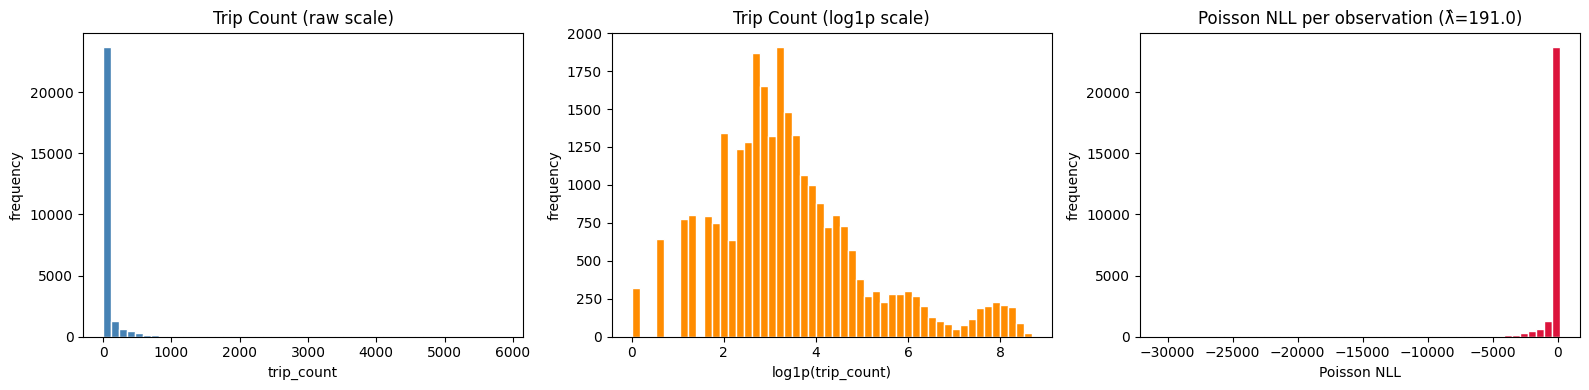

In [90]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (\u03bb\u0302={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()

## 4.2.16 Visualization: Architecture Comparison

Side-by-side comparison of the three **tuned** architectures, aggregated over seeds (mean ± std):

- **left** — train / validation / test loss, all under the training criterion (`config.LOSS`), so the three bars per architecture share one scale and gaps indicate over-/underfitting;
- **right** — test-set MAE on the raw trip-count scale (the headline metric).


Training criterion: mae (log1p scale), 1 seed(s)

               train_loss         val_loss        test_loss               mae
Baseline  0.2289 ± 0.0000  0.3045 ± 0.0000  0.3463 ± 0.0000  46.3880 ± 0.0000
Deeper    0.2814 ± 0.0000  0.3130 ± 0.0000  0.3533 ± 0.0000  66.4877 ± 0.0000
Wider     0.2208 ± 0.0000  0.3116 ± 0.0000  0.3483 ± 0.0000  50.4808 ± 0.0000


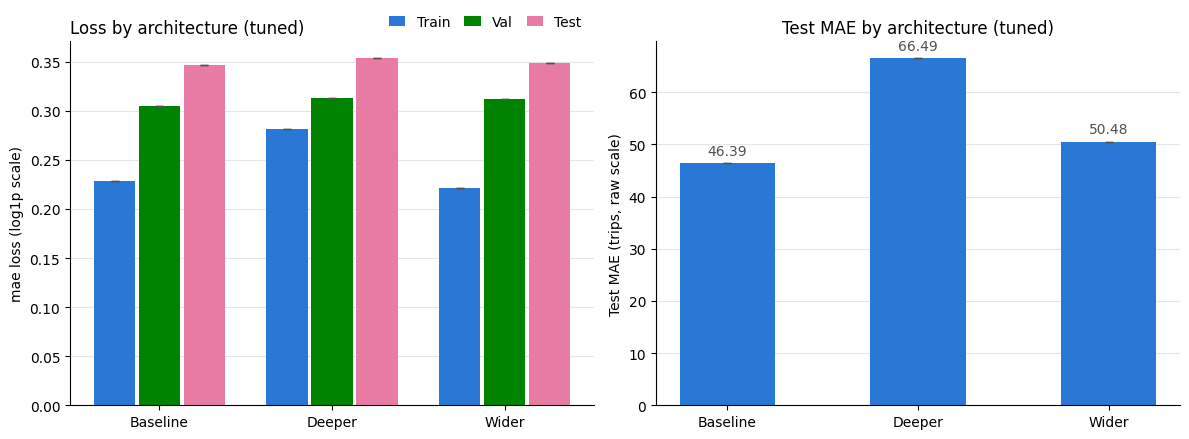

In [91]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Architecture Comparison  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# One figure over the three tuned architectures:
#   left  — train / val / test loss under the training criterion (mean ± std over seeds)
#   right — test-set MAE on the raw trip-count scale (mean ± std over seeds)
# Test loss is computed here with the same criterion as training, so the three
# bars per architecture are directly comparable (matching the overfitting-check
# in evaluate_models, which now also uses the training criterion).

import matplotlib.pyplot as plt

ARCH_RUNS = {
    "Baseline": (tuned_models,        tuned_train_losses,        tuned_val_losses),
    "Deeper":   (tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses),
    "Wider":    (tuned_wider_models,  tuned_wider_train_losses,  tuned_wider_val_losses),
}

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y_target = y_test if IS_POISSON else np.log1p(y_test)   # test target on the training scale

def _test_loss_and_mae(model):
    """Per-seed test loss (training criterion) and raw-scale test MAE."""
    model.eval()
    with torch.no_grad():
        preds_raw = model(_X_test_t, _g_test_t).cpu().numpy().flatten()
    if config.LOSS == "mae":
        test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
    elif config.LOSS == "mse":
        test_loss = float(np.mean((preds_raw - _y_target) ** 2))
    elif config.LOSS == "poisson_nll":
        test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
    else:  # nb_nll — evaluate with the model's trained dispersion
        test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                      torch.as_tensor(_y_target, dtype=torch.float32),
                                      model.log_theta.detach().cpu()))
    preds = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    return test_loss, float(np.mean(np.abs(preds - y_test)))

stats = {}
for _label, (_models, _tr, _vl) in ARCH_RUNS.items():
    _per_seed = [_test_loss_and_mae(m) for m in _models]
    stats[_label] = {
        "train_loss": (np.mean(_tr), np.std(_tr)),
        "val_loss":   (np.mean(_vl), np.std(_vl)),
        "test_loss":  (np.mean([t for t, _ in _per_seed]), np.std([t for t, _ in _per_seed])),
        "mae":        (np.mean([m for _, m in _per_seed]), np.std([m for _, m in _per_seed])),
    }

summary_df = pd.DataFrame(
    {a: {k: f"{m:.4f} ± {s:.4f}" for k, (m, s) in d.items()} for a, d in stats.items()}
).T
print(f"Training criterion: {config.LOSS} ({'raw counts' if IS_POISSON else 'log1p scale'}), "
      f"{len(SEEDS)} seed(s)\n")
print(summary_df.to_string())

_archs  = list(stats)
_splits = [("train_loss", "Train", "#2a78d6"),
           ("val_loss",   "Val",   "#008300"),
           ("test_loss",  "Test",  "#e87ba4")]

fig, (ax_loss, ax_mae) = plt.subplots(1, 2, figsize=(12, 4.5))
_x = np.arange(len(_archs))

for _i, (_split, _sl, _c) in enumerate(_splits):
    _means = [stats[a][_split][0] for a in _archs]
    _stds  = [stats[a][_split][1] for a in _archs]
    ax_loss.bar(_x + (_i - 1) * 0.26, _means, width=0.24, color=_c, label=_sl,
                yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
ax_loss.set_xticks(_x, _archs)
ax_loss.set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
ax_loss.set_title("Loss by architecture (tuned)", loc="left")
ax_loss.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

_means = [stats[a]["mae"][0] for a in _archs]
_stds  = [stats[a]["mae"][1] for a in _archs]
ax_mae.bar(_x, _means, width=0.5, color="#2a78d6",
           yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
for _xi, _m, _s in zip(_x, _means, _stds):
    ax_mae.annotate(f"{_m:.2f}", (_xi, _m + _s), ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="#52514e")
ax_mae.set_xticks(_x, _archs)
ax_mae.set_ylabel("Test MAE (trips, raw scale)")
ax_mae.set_title("Test MAE by architecture (tuned)")

for _ax in (ax_loss, ax_mae):
    _ax.grid(axis="y", color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

plt.tight_layout()
plt.show()


### Learning Curves

Per-epoch train / validation / test loss for each tuned architecture, all under the training criterion. The dot marks the best-validation epoch whose weights early stopping restores. Requires re-running the tuned training cells once, since `train_model` now records the history on the returned models.


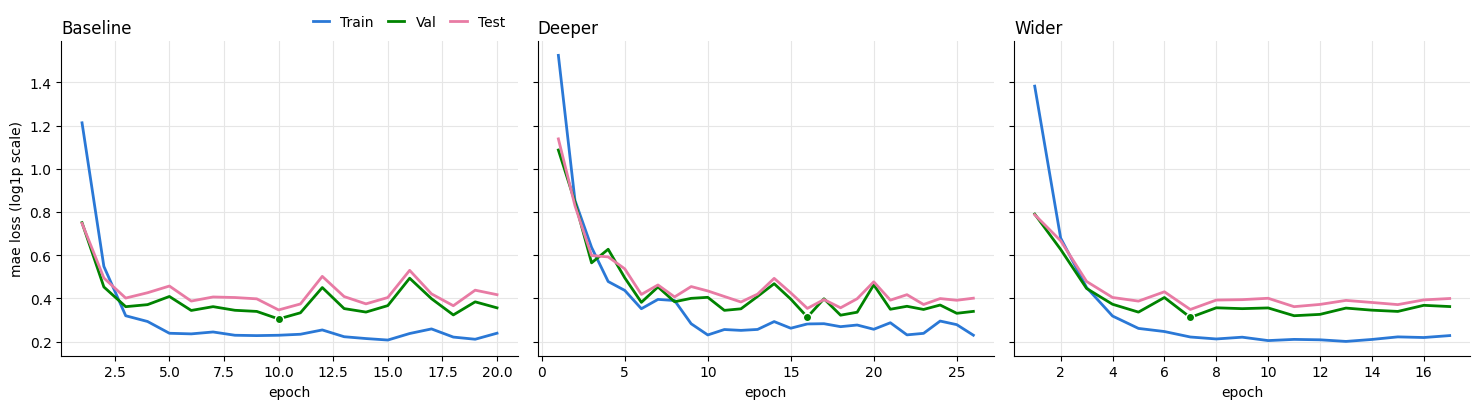

In [92]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Learning Curves          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Per-epoch train / val / test loss for the three tuned architectures.
# train_model records the history on each returned model; the tuned training
# cells pass test_data so the test curve is monitored per epoch too
# (monitoring only — it never influences training or model selection).

import matplotlib.pyplot as plt

ARCH_CURVES = {
    "Baseline": tuned_models,
    "Deeper":   tuned_deeper_models,
    "Wider":    tuned_wider_models,
}
_colors = {"train": "#2a78d6", "val": "#008300", "test": "#e87ba4"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for _ax, (_label, _models) in zip(axes, ARCH_CURVES.items()):
    for _si, _model in enumerate(_models):
        _h = getattr(_model, "history", None)
        if _h is None:
            raise RuntimeError("model has no training history — re-run the tuned "
                               "training cells (train_model records it now)")
        _epochs = np.arange(1, len(_h["train"]) + 1)
        for _split in ("train", "val", "test"):
            if _h[_split]:
                _ax.plot(_epochs, _h[_split], color=_colors[_split], lw=2,
                         alpha=1.0 if _si == 0 else 0.4,
                         label=_split.capitalize() if _si == 0 else None)
        _best = int(np.argmin(_h["val"]))   # epoch restored by early stopping
        _ax.plot(_best + 1, _h["val"][_best], "o", ms=6, color=_colors["val"],
                 markeredgecolor="white", zorder=3)
    _ax.set_title(_label, loc="left")
    _ax.set_xlabel("epoch")
    _ax.grid(color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

axes[0].set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.show()


### Statistical Significance — Wilcoxon Signed-Rank

Non-parametric paired test of whether each **tuned** network is more accurate than the benchmark models on the held-out test set, using per-row absolute errors (the tuned architectures are seed-ensembled — mean predicted count). Every model scores the same test rows, so the errors are paired. Reported with a Holm-corrected one-sided *p*-value (H1: NN error < benchmark error) and practical effect sizes, since on a test set this large even trivial gaps come out "significant".

This test aims to **identify whether a model adds value, not whether neural networks should be deployed**. If the difference in performance is not statistically significant, the model adds no measurable value over the benchmark. If it is significant, further analysis is needed to determine whether that value justifies the cost.

In [93]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Statistical Significance (Wilcoxon)     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Wilcoxon signed-rank test: is each tuned NN more accurate than the benchmarks?
# Per-row absolute errors on the held-out test set; the tuned architectures are
# seed-ensembled (mean predicted count). Every model scores the same test rows,
# so the errors are paired. One-sided H1: NN abs-error < benchmark abs-error.
# p-values are Holm-corrected across all comparisons, and because a test set this
# large makes even trivial gaps "significant", the practical effect sizes
# (median abs-error reduction, share of rows the NN wins) are shown alongside.

from scipy.stats import wilcoxon

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y        = np.asarray(y_test, dtype=float)


def _nn_ensemble_preds(models):
    """Seed-ensembled predicted counts (raw trip-count scale) on the test set."""
    acc = np.zeros(len(_y), dtype=float)
    for _m in models:
        _m.eval()
        with torch.no_grad():
            _pr = _m(_X_test_t, _g_test_t).cpu().numpy().flatten()
        acc += np.exp(_pr) if IS_POISSON else np.expm1(_pr)
    return acc / len(models)


nn_preds = {
    "Baseline (tuned)": _nn_ensemble_preds(tuned_models),
    "Deeper (tuned)":   _nn_ensemble_preds(tuned_deeper_models),
    "Wider (tuned)":    _nn_ensemble_preds(tuned_wider_models),
}
benchmark_preds = {
    "Historical mean": np.asarray(hist_mean_preds, dtype=float),
    "Ridge":           np.asarray(ridge_preds,     dtype=float),
}

_rows = []
for _mname, _mpred in nn_preds.items():
    _ae_nn = np.abs(_mpred - _y)
    for _bname, _bpred in benchmark_preds.items():
        _ae_bm = np.abs(_bpred - _y)
        _diff  = _ae_nn - _ae_bm
        _stat, _p = wilcoxon(_ae_nn, _ae_bm, alternative="less", zero_method="wilcox")
        _rows.append({
            "NN model"            : _mname,
            "Benchmark"           : _bname,
            "median AE (NN)"      : float(np.median(_ae_nn)),
            "median AE (bench)"   : float(np.median(_ae_bm)),
            "median AE reduction" : float(np.median(_ae_bm) - np.median(_ae_nn)),
            "NN wins %"           : float(100.0 * np.mean(_ae_nn < _ae_bm)),
            "W"                   : float(_stat),
            "p (one-sided)"       : float(_p),
            "n (non-tied)"        : int(np.sum(_diff != 0)),
        })

sig_df = pd.DataFrame(_rows)

# Holm-Bonferroni step-down correction across all comparisons
_pv  = sig_df["p (one-sided)"].to_numpy()
_ord = np.argsort(_pv)
_adj = np.empty_like(_pv)
_run = 0.0
for _rank, _idx in enumerate(_ord):
    _run = max(_run, (len(_pv) - _rank) * _pv[_idx])
    _adj[_idx] = min(_run, 1.0)
sig_df["p (Holm)"]    = _adj
sig_df["significant"] = sig_df["p (Holm)"] < 0.05

print("Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks")
print(f"paired over {len(_y):,} test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05\n")
with pd.option_context("display.width", 200, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.4g}"):
    print(sig_df.to_string(index=False))


Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks
paired over 4,216 test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05

        NN model       Benchmark  median AE (NN)  median AE (bench)  median AE reduction  NN wins %         W  p (one-sided)  n (non-tied)   p (Holm)  significant
Baseline (tuned) Historical mean           5.361              8.328                2.967      71.18 2.325e+06     9.124e-159          4216 2.737e-158         True
Baseline (tuned)           Ridge           5.361              10.37                5.005      71.13 2.006e+06     2.566e-209          4216 1.283e-208         True
  Deeper (tuned) Historical mean           5.094              8.328                3.235      67.98 2.739e+06     1.329e-103          4216 1.329e-103         True
  Deeper (tuned)           Ridge           5.094              10.37                5.272      71.32 2.019e+06     3.896e-207          4216 1.558e-206         True
   Wider (tuned) Historical mean      